# Belt Road

Edit `bandage`, `preference`, `diagram_mode`, `face_colors`, and the `graph_*` options before running the cells using the **v2/.venv** kernel, with GAP on `PATH`.


In [1]:
import bce_v2 as c
from bce_v2.notebook import refresh_renderers
from IPython.display import Markdown, display

refresh_renderers()

bandage = [
    0, 0, 0,
    0, 0, 0,
    1, 0, 0,

    7, 6, 5,
    8, 0, 4,
    1, 2, 3,

    7, 6, 5,
    8, 0, 4,
    1, 2, 3,
]

preference = "memory"
diagram_mode = c.DiagramMode.OPPOSITE_CORNERS
face_colors = {
    'U': 'white', 'R': 'red', 'F': 'green',
    'D': 'yellow', 'L': 'orange', 'B': 'blue',
}

analysis = c.analyze_isotropy(bandage)
display(Markdown(
    "| Shapes | Isotropy group size | Total scrambles |\n"
    "| ---: | ---: | ---: |\n"
    f"| {analysis.loops.shape_count:,} | {analysis.group_order:,} | {analysis.colored_state_count:,} |"
))

| Shapes | Isotropy group size | Total scrambles |
| ---: | ---: | ---: |
| 92,176 | 10,368 | 955,680,768 |

Compile the staged guide. Graph rendering is a separate optional cell below.
Progress is optionally printed while compiling. The 120-second optimization budget starts after a certified baseline is available.


# Solution from solved shape

This computational method covers all **10,368 reachable colored states** whose bandage shape is already the declared reference shape.

In each stage's diagrams: face centers are colored to inform you how to orient the cube before algorithm application. Blocks already solved are dark grey. The block this stage requires you to identify is colored. Striped white color indicates a white sticker, plain white indicates unsolved sticker of any color.

## Algorithms

Singmaster notation uses U/R/F/D/L/B, an apostrophe for an inverse turn, 2 for a half turn, x/y/z represent whole cube rotations 90° in the direction of an R/U/F move respectively. Structured recipes use `[A, B] = A B A⁻¹ B⁻¹`, `S^A = A⁻¹ S A`, and signed powers; a negative power executes the inverse algorithm.

| Turn sequence | Block action | Structure |
| --- | --- | --- |
| `M1: F' B' U2 B F` | `(UBL UFR)(UL UR)([BL-DBL] [FR-DFR])` | `U2^(B F)` |
| `M2: R L U2 L' R'` | `(UBL UFR)(UB UF)([BL-DBL] [FR-DFR])` | `U2^(L' R')` |
| `M3: F U2 F' U L' U2 L` | `(UBL-)(UB+ UR UF UL)(UBR-)([UFL-FL-DFL]+)(UFR-)` | `U2^F' U U2^L` |
| `M4: B' R B' R' B2 L U2 L'` | `(UBL-)(UB+ UR+ UF)(UBR-)(UFR-)` | `B' B'^R' B2 U2^L'` |
| `M8: B L U L' B' R' F' U' F R` | `(UL+ UR UF+)` | `U^(L' B') U'^(F R)` |
| `M9: B' R B R' L U' R' U L' R` | `(UB+ UF UR+)` | `[B', R] [L U', R']` |
| `M10: B' R' F' U2 F R B L U2 L'` | `(UB+ UL+ UF)` | `U2^(F R B) U2^L'` |
| `M12: F B U2 B' F' L' R' U2 L R` | `(UB UF)(UL UR)` | `U2^(B' F') (R' U2)^L R` |
| `M13: F U R U' B U2 B' R' U F'` | `(UBL+)(UB+ UL+ UF+ UR)(UBR+)([UFL-FL-DFL]+)(UFR+)` | `(R^U' U2^B' R' U)^F'` |
| `M14: F U R U2 R' F' U' L' U2 L` | `(UB UF+)(UL+ UR)` | `(U U2^R')^F' U' U2^L` |
| `M15: F' B U B' U' B' F R B R'` | `(UB UL+ UR+)` | `B'^(U' B' F) B^R'` |
| `M16: F' U' F R B L U L' B' R'` | `(UB UL+ UF+)` | `U'^F U^(L' B' R')` |
| `M19: F U R' U' F2 U2 F2 U R U' F'` | `(UBL+ UBR-)(UL UR)([BR-DBR] [FR-DFR])` | `U2^(F2 R^U' F')` |
| `M20: F' U' F' R2 L2 B D B' L2 R2 F2` | `(UB UF UR)` | `F' U' F' D^(B' L2 R2) F2` |
| `M23: L' U' B U L2 U2 L2 U' B' U L` | `(UB UF)(UBR+ UFR-)([BL-DBL] [BR-DBR])` | `U2^(L2 B'^U L)` |
| `M24: R B' R F2 B2 L' B L B2 F2 R2` | `(UB+ UR UL+)` | `R B' R B^(L B2 F2) R2` |

### Shared piece recipes

| Piece | Turn sequence |
| --- | --- |
| `C1` | `R B R'` |
| `C2` | `B U2 B'` |
| `C3` | `F R B` |
| `C4` | `L' U2 L` |

| Algorithm | Recipe |
| --- | --- |
| `M1` | `(F' B') (U2) (F' B')^-1` |
| `M2` | `(R L) (U2) (R L)^-1` |
| `M3` | `y2 (C2) y2 U C4` |
| `M4` | `B' C1^-1 B2 y (C2) y'` |
| `M8` | `B x z2 (C1) z2 x' C3^-1 U' F R` |
| `M9` | `B' C1 L U' R' U L' R` |
| `M10` | `C3^-1 U2 C3 y (C2) y'` |
| `M12` | `F C2 F' L' R' U2 L R` |
| `M13` | `(F) (x' y' (C1) y x C2 R' U) (F)^-1` |
| `M14` | `F U y' (C2) y F' U' C4` |
| `M15` | `F' x z' (C1) z x' U' B' C3 R'` |
| `M16` | `F' U' C3 x z2 (C1) z2 x' B' R'` |
| `M19` | `(F x' y' (C1^-1) y x F2) (U2) (F x' y' (C1^-1) y x F2)^-1` |
| `M20` | `F' U' F' R2 L2 x' z (C1) z' x L2 R2 F2` |
| `M23` | `(L' U' B U L2) (U2) (L' U' B U L2)^-1` |
| `M24` | `R B' R F2 B2 L' y (C1) y' B' F2 R2` |

## Stage 1: Orient 311 UFL-FL-DFL

This stage has 2 exact cases and 1 instruction family. It reduces the remaining possibilities from 10,368 to 5,184.

### Case 1

Skip — already correct

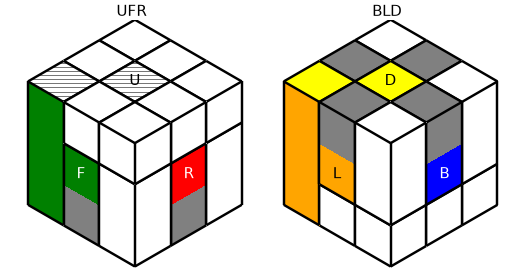

### Case 2

Execute `M3: F U2 F' U L' U2 L`.

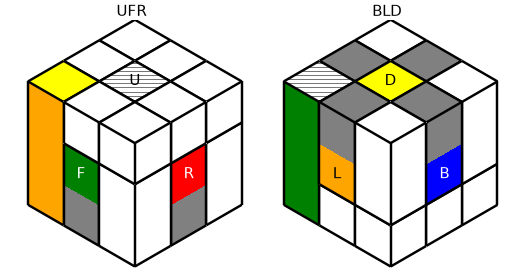

## Stage 2: Solve Pair BL-DBL

This stage has 3 exact cases and 2 instruction families. It reduces the remaining possibilities from 5,184 to 1,728.

### Case 1

Skip — already correct

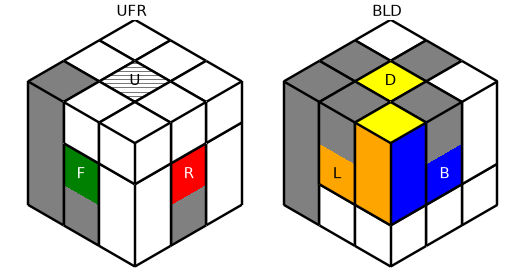

### Case 2

Execute `M23: L' U' B U L2 U2 L2 U' B' U L`.

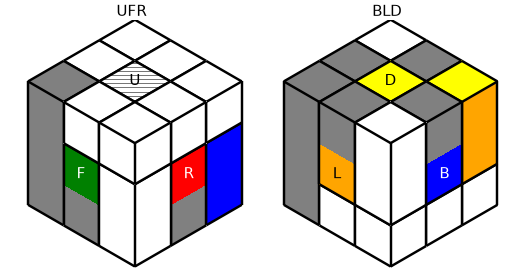

### Case 3

Execute `M1: F' B' U2 B F`.

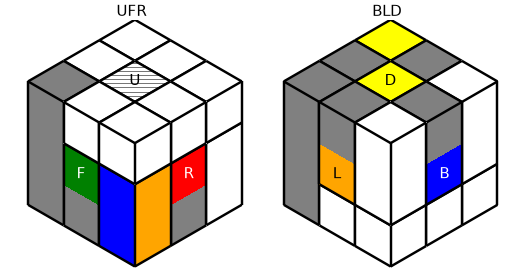

Also correct automatically after this stage: place Corner UFR; place Pair BL-DBL.

## Stage 3: Solve Pair BR-DBR

This stage has 2 exact cases and 1 instruction family. It reduces the remaining possibilities from 1,728 to 864.

### Case 1

Skip — already correct

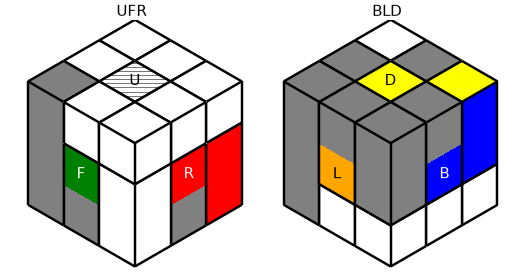

### Case 2

Execute `M19: F U R' U' F2 U2 F2 U R U' F'`.

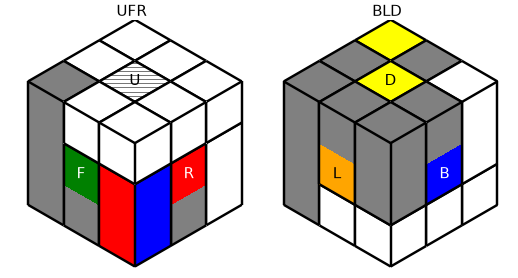

Also correct automatically after this stage: place Corner UBL; place Corner UBR; place Pair BR-DBR; place Pair FR-DFR; fully solve Pair FR-DFR.

## Stage 4: Orient Corner UBL

This stage has 3 exact cases and 1 instruction family. It reduces the remaining possibilities from 864 to 288.

### Case 1

Skip — already correct

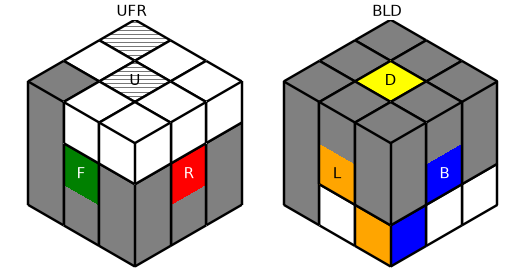

### Case 2

Execute `M4: B' R B' R' B2 L U2 L'`.

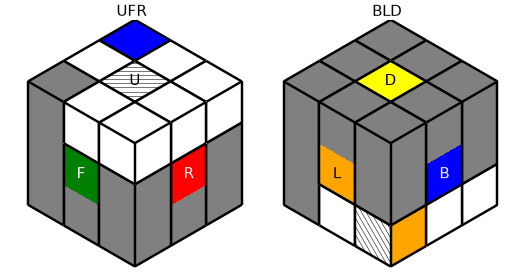

### Case 3

Execute `M4^-1: L U2 L' B2 R B R' B`.

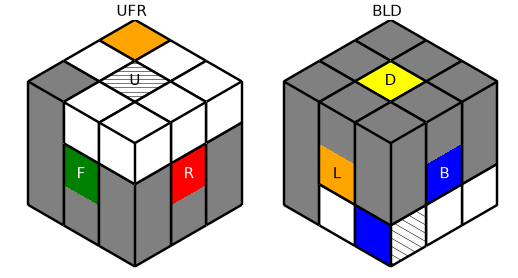

## Stage 5: Orient Corner UBR

This stage has 3 exact cases and 2 instruction families. It reduces the remaining possibilities from 288 to 96.

### Case 1

Skip — already correct

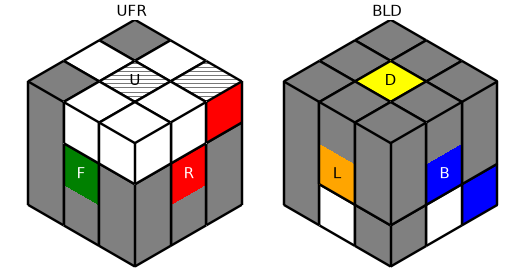

### Case 2

Execute `M23^(M3^-1) (M19^(M1^-1))^-1: F U2 F' U L' U B U L2 U2 L2 U' B' U' L U' F U2 F2 B' U2 B F2 U R' U' F2 U2 F2 U R U' F2 B' U2 B F`.

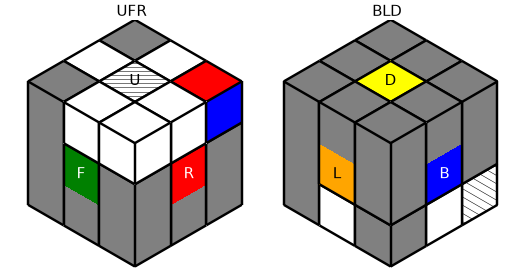

### Case 3

Execute `((M23^(M3^-1) (M19^(M1^-1))^-1)^((())^-1))^-1: F' B' U2 B F2 U R' U' F2 U2 F2 U R U' F2 B' U2 B F2 U2 F' U L' U B U L2 U2 L2 U' B' U' L U' F U2 F'`.

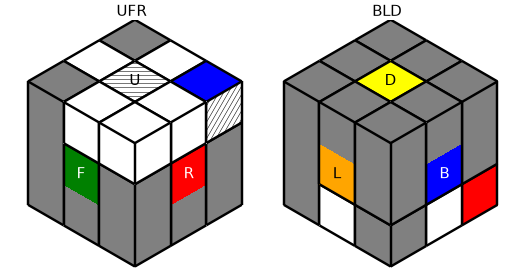

Also correct automatically after this stage: fully solve Corner UFR.

## Stage 6: Solve Edge UB

This stage has 8 exact cases and 6 instruction families. It reduces the remaining possibilities from 96 to 12.

### Case 1

Skip — already correct

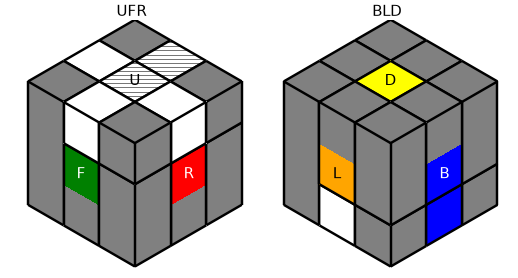

### Case 2

Execute `(M13 M3)^-1: L' U2 L U' F U R B U2 B' U R' U' F'`.

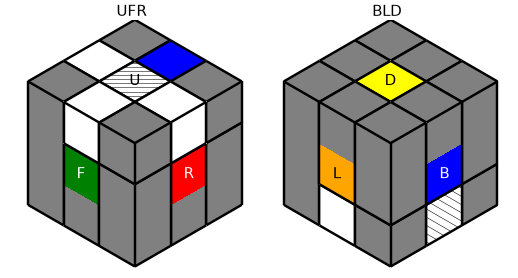

### Case 3

Execute `M16^-1: R B L U' L' B' R' F' U F`.

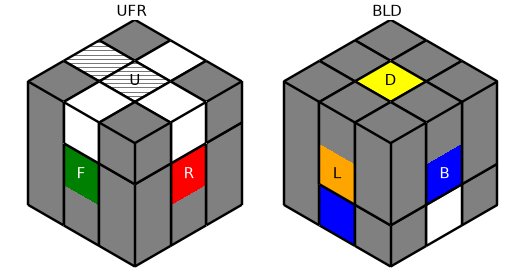

### Case 4

Execute `M10^-1: L U2 L' B' R' F' U2 F R B`.

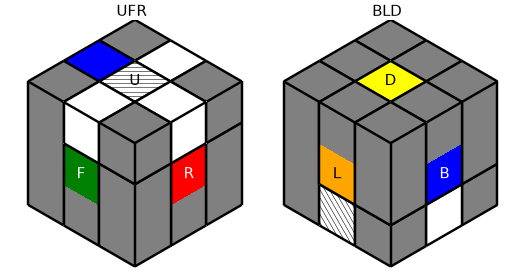

### Case 5

Execute `M20: F' U' F' R2 L2 B D B' L2 R2 F2`.

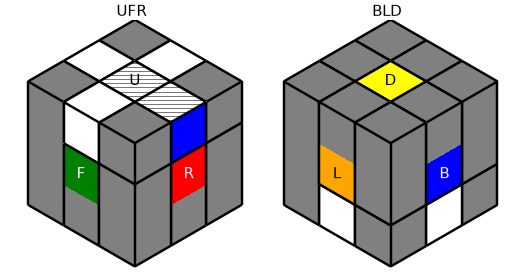

### Case 6

Execute `M9: B' R B R' L U' R' U L' R`.

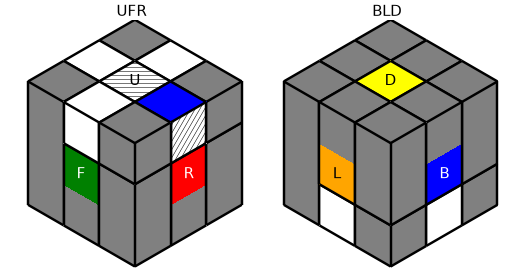

### Case 7

Execute `M14^-1: L' U2 L U F R U2 R' U' F'`.

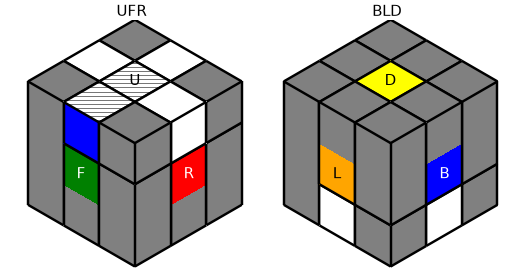

### Case 8

Execute `M16: F' U' F R B L U L' B' R'`.

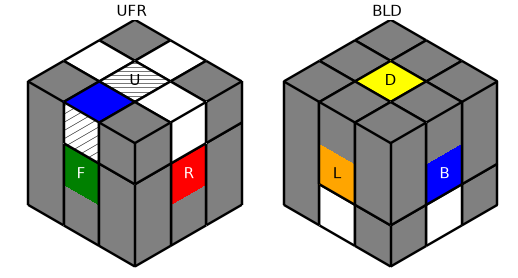

Also correct automatically after this stage: place Edge UB.

## Stage 7: Solve Edge UL

This stage has 6 exact cases and 4 instruction families. It reduces the remaining possibilities from 12 to 2.

### Case 1

Skip — already correct

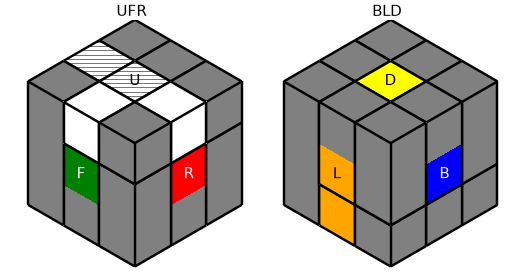

### Case 2

Execute `(((M14^-1 M12)^-1)^(M14^-1))^-1: F B U2 B' F' L' R' U2 L R L' U2 L U F R U2 R' U' F'`.

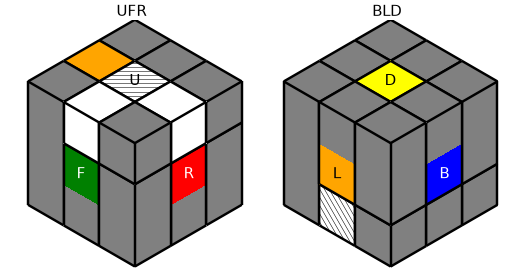

### Case 3

Execute `((M24^-1)^(M2^-1))^-1: R L U2 L' B' R F2 B2 L' B L B2 F2 R' L U2 L' R'`.

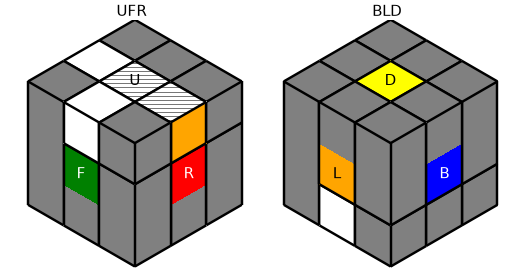

### Case 4

Execute `M8^-1: R' F' U F R B L U' L' B'`.

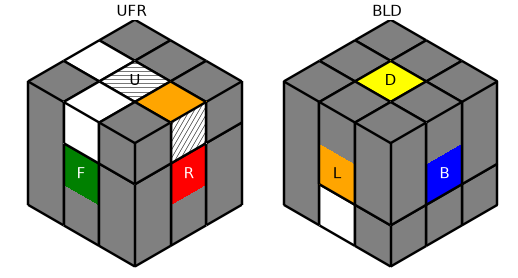

### Case 5

Execute `((M15^-1)^(M2^-1))^-1: R L U2 L' R' F' B U B' U' B' F R B L U2 L' R'`.

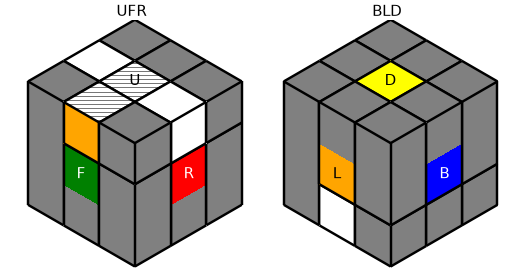

### Case 6

Execute `M8: B L U L' B' R' F' U' F R`.

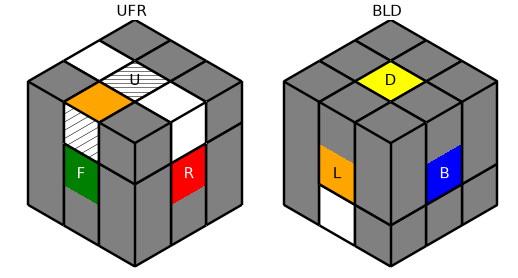

Also correct automatically after this stage: place Edge UL; place Edge UR; place Edge UF.

## Stage 8: Orient Edge UR

This stage has 2 exact cases and 1 instruction family. It reduces the remaining possibilities from 2 to 1.

### Case 1

Skip — already correct

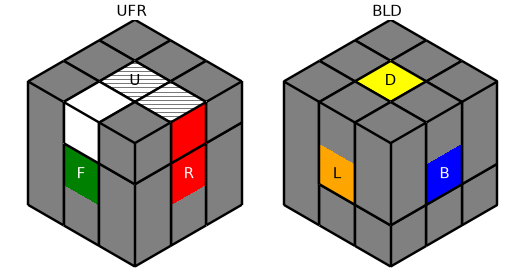

### Case 2

Execute `(M14^-1 M12)^(M2^-1): R L U2 L' R' L' U2 L U F R U2 R' U' B U2 B' F' L' R' U2 L R2 L U2 L' R'`.

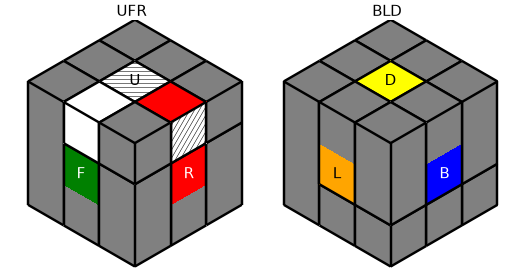

Also correct automatically after this stage: fully solve Edge UF.

After the final stage every modeled corner and edge sticker is solved. Unmarked center spin and independent virtual-core spin are outside this model.


In [3]:
repertoire = c.template_human_repertoire(analysis, preference=preference, backend="auto",
    optimization_seconds=120, progress=None,
)
display(Markdown(repertoire.write_guide(diagram_mode=diagram_mode, face_colors=face_colors)))


Optional shape graph. Configure and run the following cell when you want to draw the graph. `graph_view="auto"` draws small graphs and summarizes graphs above 1,000 shapes. Use `"local"` for a bounded neighborhood, or explicitly set `graph_view="full"` to draw every shape. Full layouts of large graphs can be expensive.


In [ ]:
import matplotlib.pyplot as plt

graph_view = "auto"  # "summary", "local", or explicit "full"
graph_max_vertices = 1000  # full auto drawings and local neighborhoods are bounded
graph_radius = 2  # used only for the local view
graph_layout = "symmetry"
graph_show_shapes = True
graph_edge_labels = True
graph_figsize = None  # automatic; override with (width, height) in inches
graph_shape_size = None  # automatic; override with a width in inches

shape_graph = c.explore(bandage)
graph_figure = c.draw_bandage_graph(
    shape_graph, view=graph_view, max_vertices=graph_max_vertices, radius=graph_radius,
    layout=graph_layout, show_shapes=graph_show_shapes,
    edge_labels=graph_edge_labels, face_colors=face_colors,
    diagram_mode=diagram_mode, figsize=graph_figsize, shape_size=graph_shape_size,
)
display(graph_figure)
plt.close(graph_figure)
